**FASE 1: Configuración y Entorno de Desarrollo**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv
/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv
/kaggle/input/datasets/alondramsoto/tmdb-5000-movie-dataset-er/TMDB_5000_Movie_Dataset_E_R.drawio.png


In [2]:
df_credits = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv')
df_movies = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv')

In [3]:
df_credits

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...
4798,9367,El Mariachi,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,72766,Newlyweds,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,231617,"Signed, Sealed, Delivered","[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,126186,Shanghai Calling,"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


In [4]:
df_movies

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",NaN,9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]","[{""iso_3166_1"": ""MX"", ""name"": ""Mexico""}, {""iso...",1992-09-04,2040920,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238
4799,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",NaN,72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],[],2011-12-26,0,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5
4800,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://www.hallmarkchannel.com/signedsealeddel...,231617,"[{""id"": 248, ""name"": ""date""}, {""id"": 699, ""nam...",en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,"[{""name"": ""Front Street Pictures"", ""

**FASE 2: Modelado Teórico y Diseño Relacional**

<img src="/kaggle/input/datasets/alondramsoto/tmdb-5000-movie-dataset-er/TMDB_5000_Movie_Dataset_E_R.drawio.png" width="800">

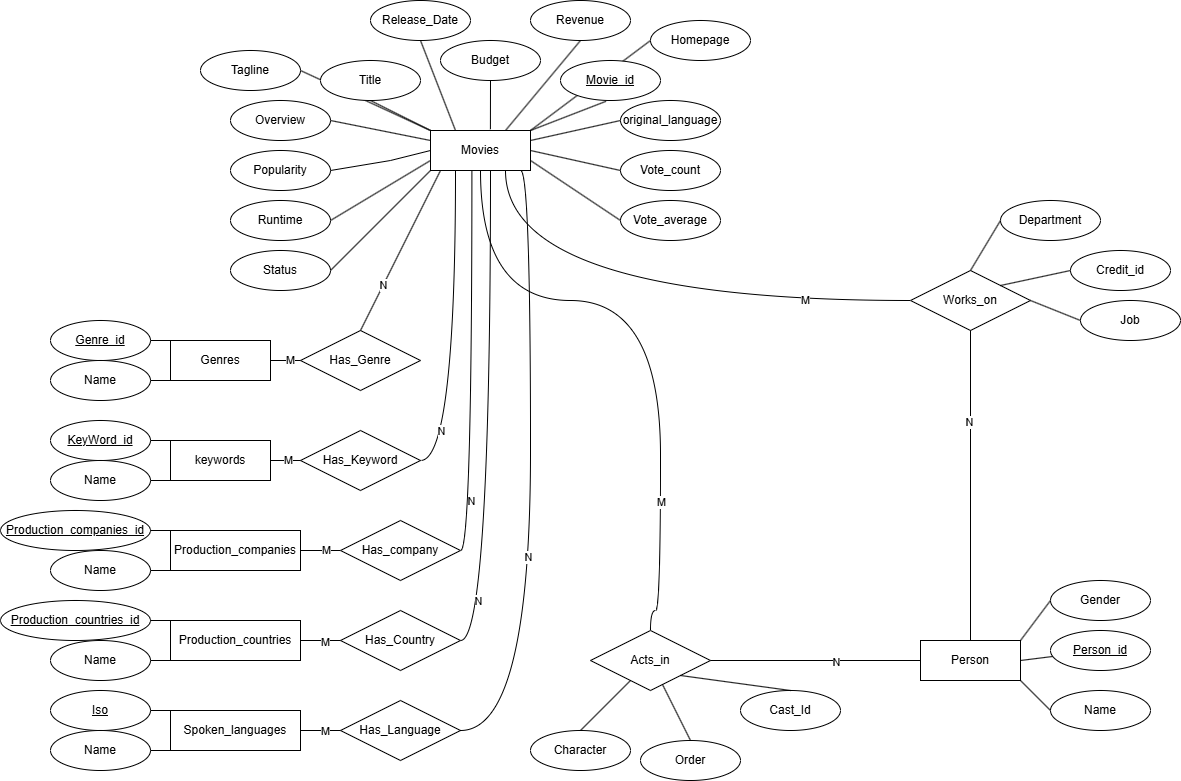

In [5]:
from IPython.display import Image, display

display(Image('/kaggle/input/datasets/alondramsoto/tmdb-5000-movie-dataset-er/TMDB_5000_Movie_Dataset_E_R.drawio.png'))

**Modelo Relacional y Normalización: Traducir el E/R a un esquema lógico.**

Movies (Movie_id(PK), title, tagline, overview, popularity, runtime, status, release_date, revenue, budget, homepage, original_language, vote_count, vote_average)

Generes (genre_id(PK), name)

Has_Genres (movie_id(FK -> Movies), genre_id(FK -> Genres) PK(Movie_id, genre_id)

Keywords(Keyword_id(PK), name)

Has_Keyword (movie_id (FK), keyword_id (FK), PK(movie_id, keyword_id))

Production_Companies (company_id (PK), name)

Has_Company (movie_id (FK), company_id (FK), PK(movie_id, company_id))

Production_Countries(country_id (PK), name)

Has_Country(movie_id (FK), country_id (FK), PK(movie_id, country_id))

Spoken_Languages(iso (PK), name)

Has_Language(movie_id (FK), iso (FK), PK(movie_id, iso))

Person(person_id (PK), name, gender)

Acts_in(movie_id (FK), person_id (FK), character, cast_id, cast_order, PK(movie_id, person_id))

Works_on(movie_id (FK), person_id (FK), department, job, credit_id, PK(movie_id, person_id, credit_id))

**Debe documentar el proceso de normalización paso a paso:**


**1NF: Identificación de atomicidad y eliminación de grupos repetitivos (listas JSON).**

Los atributos multivaluados presentes en el dataset original (genres, keywords, production_companies, production_countries, spoken_languages, cast, crew) se separan en tablas independientes y relaciones n:m.
Todas las relaciones contienen valores atómicos.
**Cumple 1NF.**

**2NF: Eliminación de dependencias parciales (creación de tablas maestras/catálogos).**

Las tablas con llaves compuestas (Has_Genres, Has_Keyword, Has_Company, Has_Country, Has_Language, Acts_in, Works_on) no presentan dependencias parciales.
Los atributos de Acts_in y Works_on dependen de la llave completa.
**Cumple 2NF.**
 
**3NF: Separación de atributos que no dependen directamente de la Llave Primaria, sino de otra columna. (Ejemplo: Si el País depende de la Ciudad y no de la Película, la ciudad y el país deben ir a su propia tabla de "Ubicaciones").**  

Se elimina la dependencia transitiva original_language → language_name creando la tabla Spoken_Languages y la relación Has_Language.
No existen atributos que dependan de otros atributos no llave.
**Cumple 3NF.**

**BCNF / 4NF: Identificar y resolver dependencias multivaluadas independientes (ej. actores vs. géneros).**

Las dependencias multivaluadas independientes (múltiples géneros, actores, compañías, países, idiomas, keywords por película) se manejan mediante tablas puente n:m.
No existen determinantes no llave.
**Cumple BCNF y 4NF.**

**FASE 3: Implementación Técnica (Python & SQL)**